# Week-10 Assignment

In [1]:
!pip -q install opencv-python-headless matplotlib kaggle

In [ ]:
import os
os.environ['KAGGLE_API_TOKEN'] = #Your kaggle api token here
print("Kaggle credentials configured.")


Kaggle credentials configured.


In [3]:
!kaggle datasets download -d moltean/fruits

Dataset URL: https://www.kaggle.com/datasets/moltean/fruits
License(s): CC-BY-SA-4.0
100% 6.79G/6.79G [00:57<00:00, 126MB/s]



In [7]:
import zipfile

with zipfile.ZipFile("fruits.zip", "r") as zip_ref:
    zip_ref.extractall("dataset")

print("Extraction complete!")

Extraction complete!


In [8]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8,8)

# Reusable Utilities

These helper routines keep image loading, display, conversion, and saving consistent across the experiments.


In [9]:
def read_rgb(path):
    """
    Read image using OpenCV and convert BGR to RGB.
    """
    img = cv.imread(path)

    if img is None:
        raise FileNotFoundError(path)

    return cv.cvtColor(img, cv.COLOR_BGR2RGB)

In [10]:
def show(title, image, cmap=None):
    plt.figure(figsize=(6,6))
    plt.imshow(image, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()

In [11]:
def show_many(images, titles, cmap=None):

    n = len(images)

    plt.figure(figsize=(5*n,5))

    for i in range(n):

        plt.subplot(1,n,i+1)

        if cmap is None:
            plt.imshow(images[i])
        else:
            plt.imshow(images[i], cmap=cmap)

        plt.title(titles[i])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [12]:
def rgb_to_hsv(image):
    return cv.cvtColor(image, cv.COLOR_RGB2HSV)

In [13]:
def bgr_to_rgb(image):
    return cv.cvtColor(image, cv.COLOR_BGR2RGB)

In [14]:
def display_bgr_vs_rgb(path):

    bgr = cv.imread(path)
    rgb = cv.cvtColor(bgr, cv.COLOR_BGR2RGB)

    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.imshow(bgr)
    plt.title("Raw BGR")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(rgb)
    plt.title("Converted RGB")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

---

# Part A — Colour-Based Fruit Segmentation

This part uses RGB and HSV representations to separate fruit pixels from a light background. It covers channel inspection, hue-based masks, threshold selection, and a brightness adjustment experiment.


In [15]:
BASE = "/content/dataset/fruits-360_100x100/fruits-360/Training"

In [16]:
from pathlib import Path
import glob

BASE = "/content/dataset/fruits-360_100x100/fruits-360/Training"

def first_image(folder):
    files = sorted(glob.glob(f"{BASE}/{folder}/*.jpg"))
    if not files:
        raise FileNotFoundError(f"No images found in {folder}")
    return files[0]

RED_APPLE = first_image("Apple Red 1")
GREEN_APPLE = first_image("Apple Granny Smith 1")
BANANA = first_image("Banana 1")
STRAWBERRY = first_image("Strawberry 1")
ORANGE = first_image("Orange 1")
LIME = first_image("Limes 1")

print("Dataset paths loaded successfully.")

Dataset paths loaded successfully.


In [17]:
image_path = RED_APPLE

bgr = cv.imread(image_path)

if bgr is None:
    raise FileNotFoundError(image_path)

rgb = cv.cvtColor(bgr, cv.COLOR_BGR2RGB)

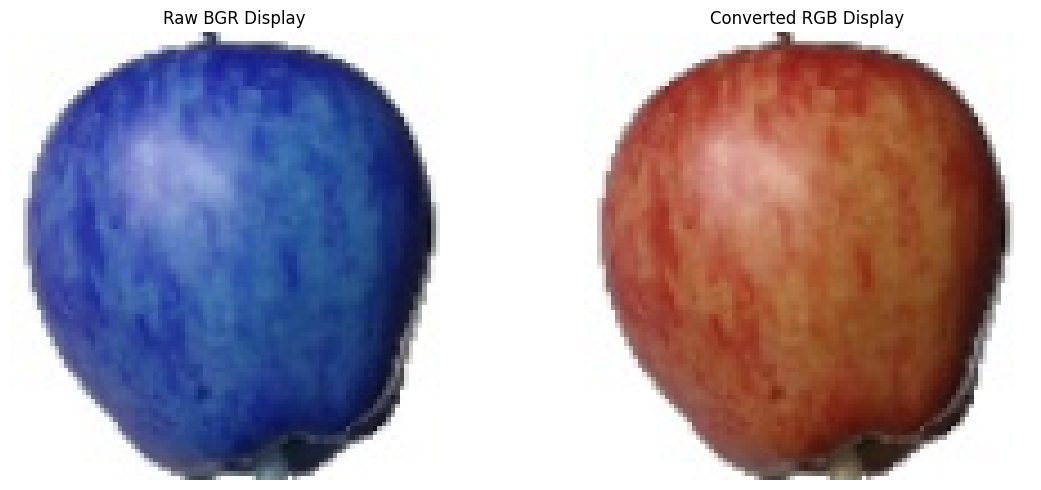

In [18]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(bgr)
plt.title("Raw BGR Display")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(rgb)
plt.title("Converted RGB Display")
plt.axis("off")

plt.tight_layout()
plt.show()

### Observation

OpenCV stores colour images as BGR, whereas Matplotlib reads channel order as RGB. As a result, showing the unconverted array swaps red and blue; converting it first restores the apple's expected appearance.


In [19]:
hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)

H, S, V = cv.split(hsv)

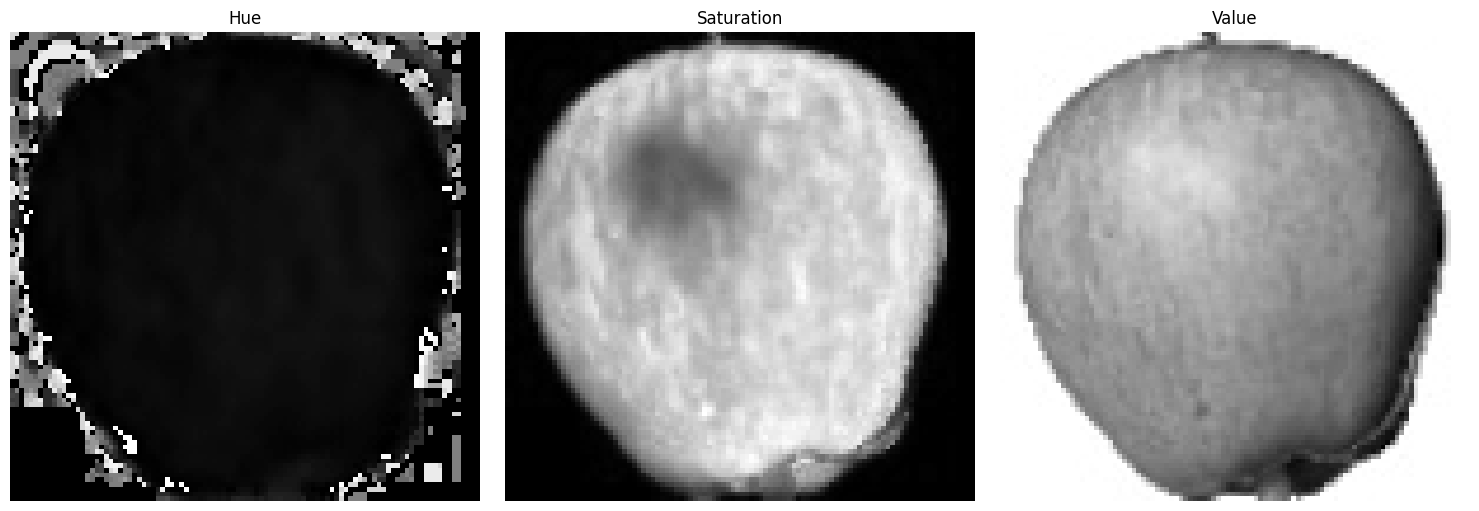

In [20]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(H, cmap="gray")
plt.title("Hue")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(S, cmap="gray")
plt.title("Saturation")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(V, cmap="gray")
plt.title("Value")
plt.axis("off")

plt.tight_layout()
plt.show()

### Channel interpretation

Hue identifies the colour family, saturation measures colour strength, and value represents brightness. Here, saturation gives the clearest fruit/background separation because the fruit is strongly coloured while the white background has little saturation.


In [21]:
lower_red1 = np.array([0, 100, 70])
upper_red1 = np.array([10, 255, 255])

lower_red2 = np.array([170, 100, 70])
upper_red2 = np.array([180, 255, 255])

In [22]:
mask1 = cv.inRange(hsv, lower_red1, upper_red1)
mask2 = cv.inRange(hsv, lower_red2, upper_red2)

mask = cv.bitwise_or(mask1, mask2)

segmented = cv.bitwise_and(rgb, rgb, mask=mask)

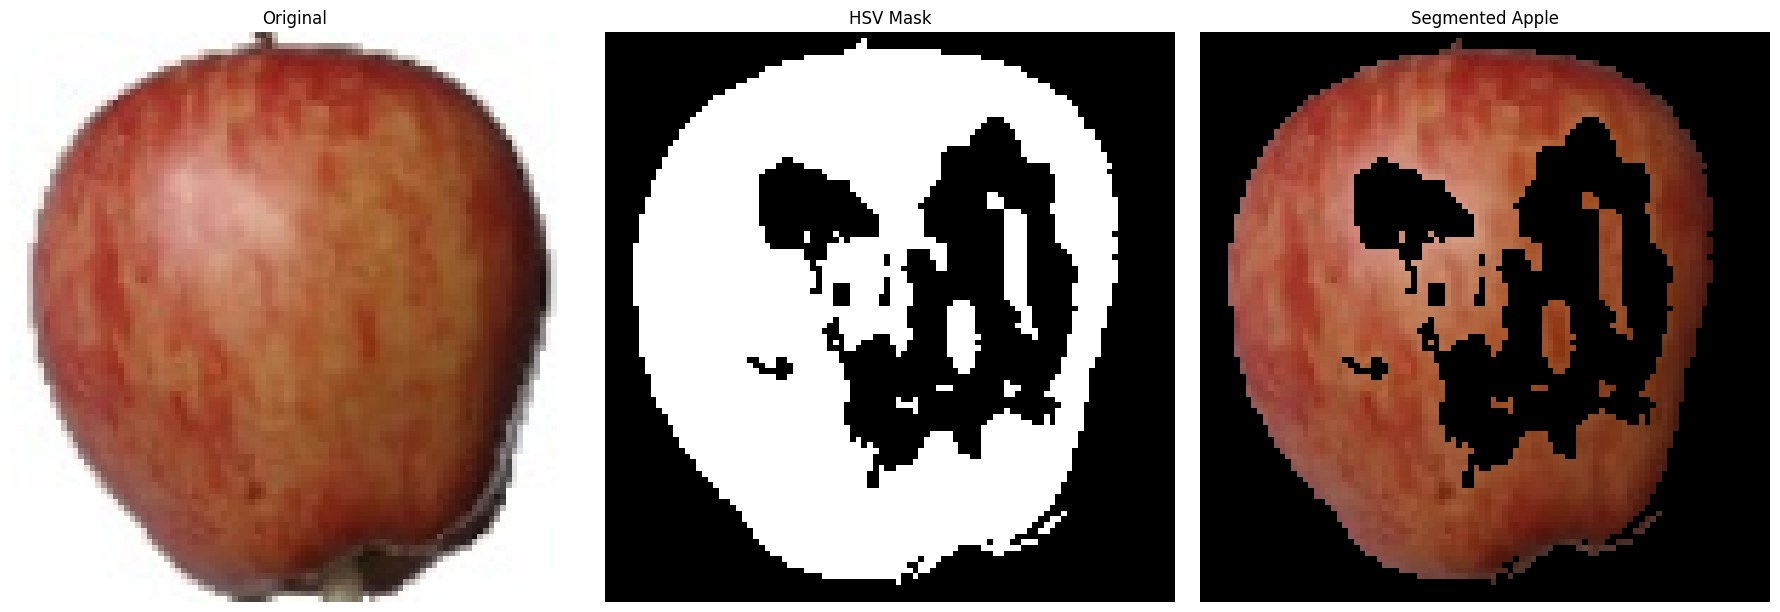

In [23]:
plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
plt.imshow(rgb)
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(mask, cmap="gray")
plt.title("HSV Mask")

plt.subplot(1,3,3)
plt.imshow(segmented)
plt.title("Segmented Apple")

for i in range(1,4):
    plt.subplot(1,3,i)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [24]:
def segment_hsv(image_path, lower, upper):
    bgr = cv.imread(image_path)

    if bgr is None:
        raise FileNotFoundError(image_path)

    rgb = cv.cvtColor(bgr, cv.COLOR_BGR2RGB)
    hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)

    mask = cv.inRange(hsv, lower, upper)
    result = cv.bitwise_and(rgb, rgb, mask=mask)

    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.imshow(rgb)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(mask, cmap="gray")
    plt.title("HSV Mask")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(result)
    plt.title("Segmented")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [25]:
GREEN_LOWER = np.array([35, 40, 40])
GREEN_UPPER = np.array([90, 255, 255])

YELLOW_LOWER = np.array([18, 80, 80])
YELLOW_UPPER = np.array([40, 255, 255])

LIME_LOWER = np.array([35, 50, 50])
LIME_UPPER = np.array([90, 255, 255])

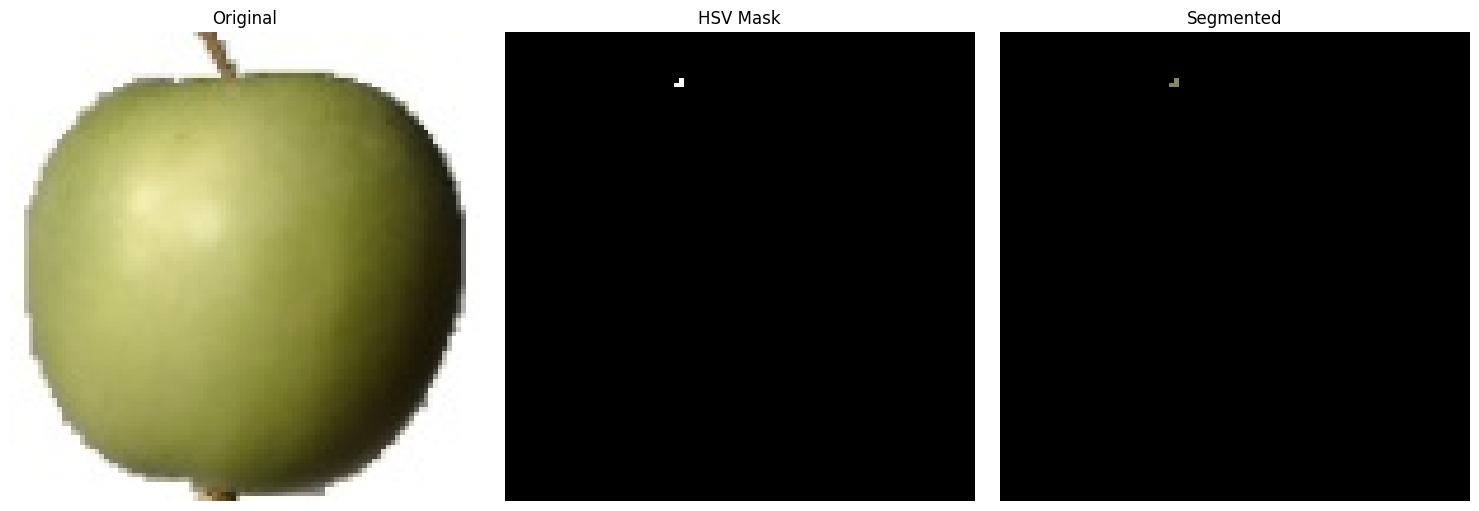

In [26]:
segment_hsv(GREEN_APPLE, GREEN_LOWER, GREEN_UPPER)

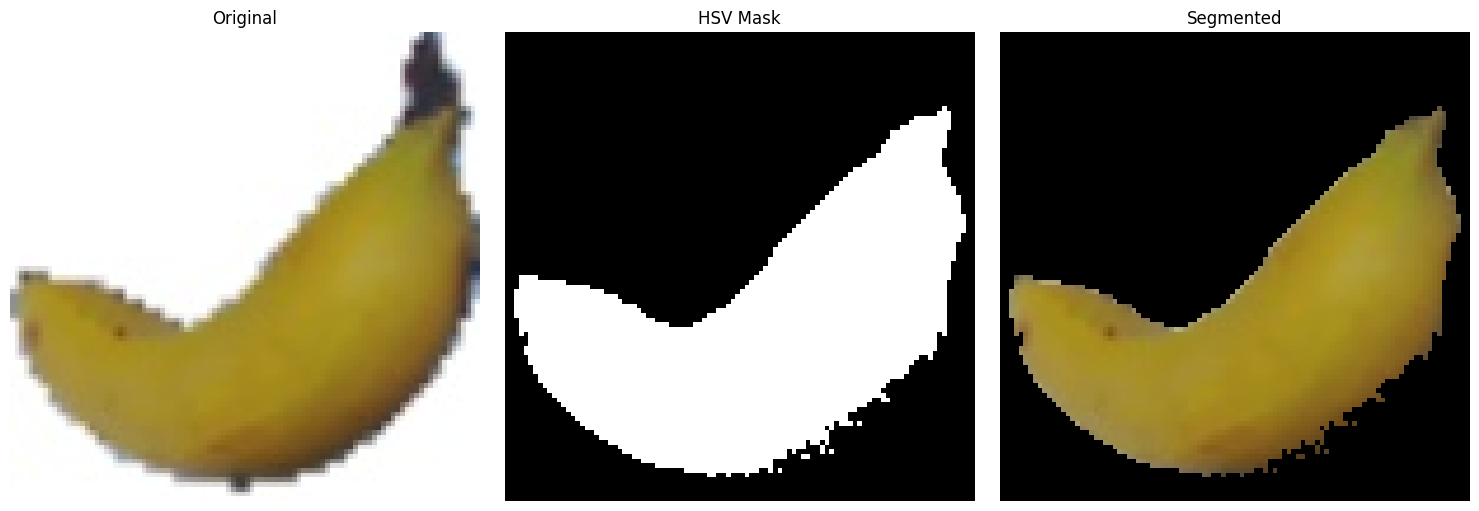

In [27]:
segment_hsv(BANANA, YELLOW_LOWER, YELLOW_UPPER)

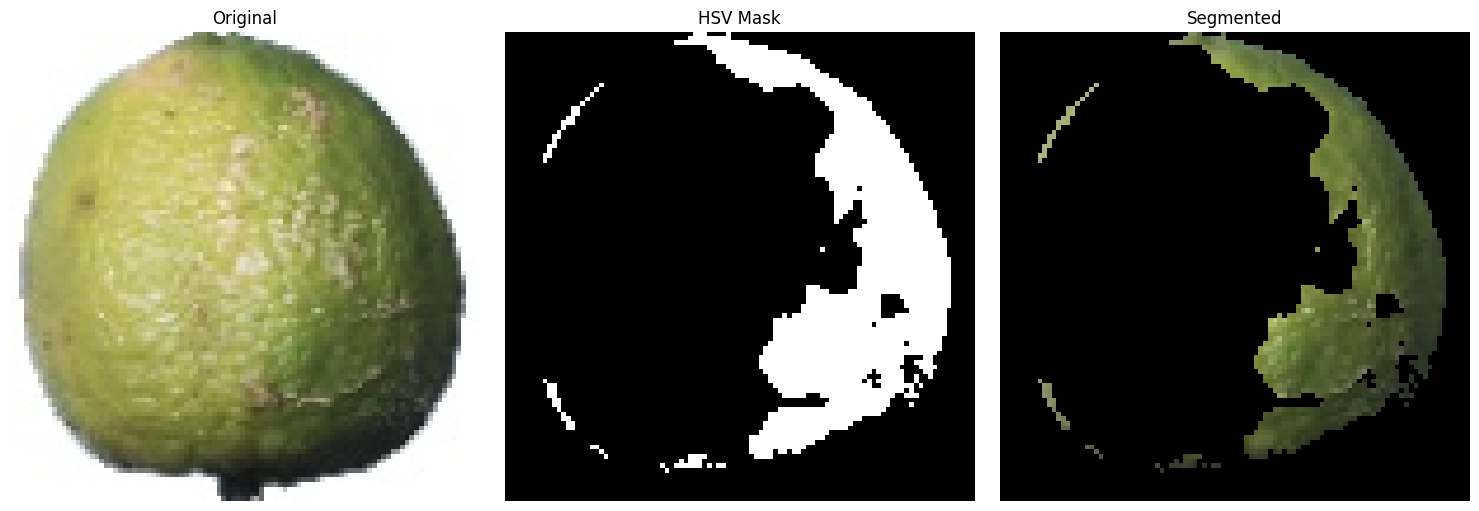

In [28]:
segment_hsv(LIME, LIME_LOWER, LIME_UPPER)

### HSV ranges used for masking

| Fruit | H Min | H Max | S Min | S Max | V Min | V Max |
|--------|------:|------:|------:|------:|------:|------:|
| Red Apple | 0 / 170 | 10 / 180 | 100 | 255 | 70 | 255 |
| Green Apple | 35 | 90 | 40 | 255 | 40 | 255 |
| Banana | 18 | 40 | 80 | 255 | 80 | 255 |
| Lime | 35 | 90 | 50 | 255 | 50 | 255 |

These settings are image-specific; they may need adjustment when illumination or camera settings change.


In [29]:
bgr = cv.imread(BANANA)
rgb = cv.cvtColor(bgr, cv.COLOR_BGR2RGB)

# Simulate a darker image
dark = (rgb * 0.5).astype(np.uint8)

In [30]:
alpha = 1.3   # Contrast
beta = 20     # Brightness

manual = np.clip(alpha * dark + beta, 0, 255).astype(np.uint8)
opencv = cv.convertScaleAbs(dark, alpha=alpha, beta=beta)

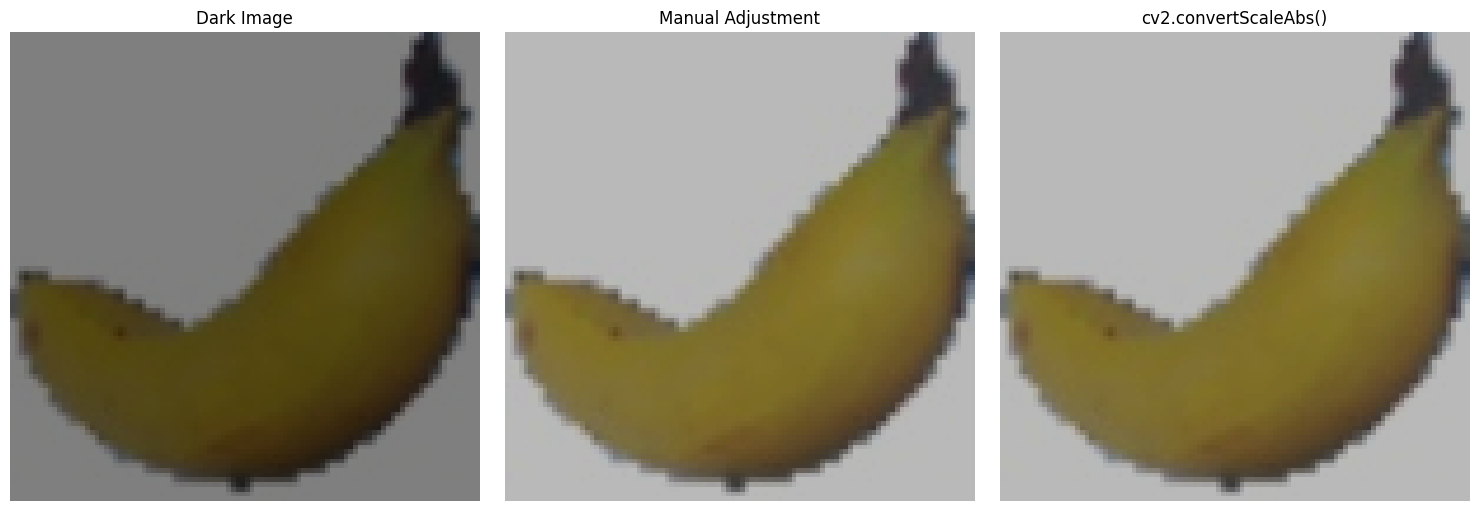

In [31]:
plt.figure(figsize=(15,5))

images = [dark, manual, opencv]
titles = ["Dark Image", "Manual Adjustment", "cv2.convertScaleAbs()"]

for i in range(3):
    plt.subplot(1,3,i+1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

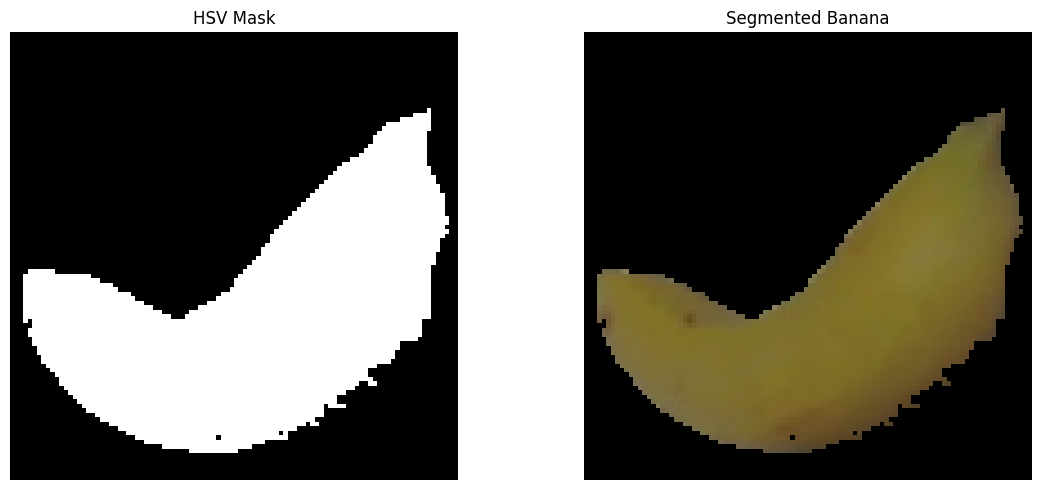

In [32]:
hsv = cv.cvtColor(cv.cvtColor(manual, cv.COLOR_RGB2BGR), cv.COLOR_BGR2HSV)

mask = cv.inRange(hsv, YELLOW_LOWER, YELLOW_UPPER)
result = cv.bitwise_and(manual, manual, mask=mask)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(mask, cmap="gray")
plt.title("HSV Mask")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(result)
plt.title("Segmented Banana")
plt.axis("off")

plt.tight_layout()
plt.show()

### Brightness and contrast result

The adjustment makes the dark banana easier to distinguish, so the yellow HSV mask becomes more dependable. The NumPy calculation and cv2.convertScaleAbs apply the same linear transformation followed by clipping, which is why their outputs are effectively the same.


## Question 6 — Reflection

HSV is usually more suitable than RGB for colour masking because hue is separated from brightness. A modest lighting change therefore affects the value channel more than the colour criterion itself. RGB thresholds are less stable because brightness changes alter all three channels.

HSV is not a complete solution: hue becomes unreliable for nearly black, weakly saturated, reflective, or heavily shadowed pixels. Dark grapes and blueberries are examples where additional lighting correction, texture cues, or a learned model may be needed.


# Part B — Histograms and Filtering

This section examines grayscale intensity distributions, contrast enhancement methods, synthetic noise, and edge-preserving denoising.


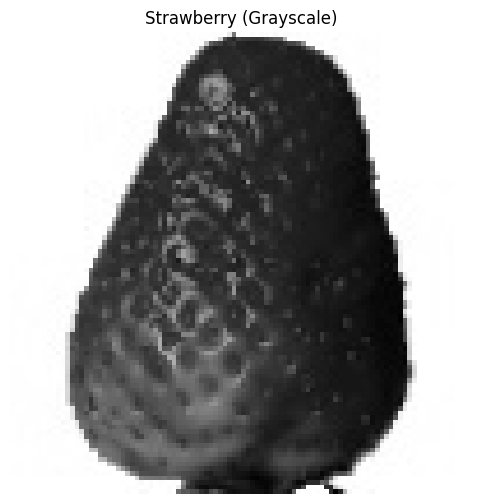

In [33]:
gray = cv.imread(STRAWBERRY, cv.IMREAD_GRAYSCALE)

if gray is None:
    raise FileNotFoundError(STRAWBERRY)

plt.figure(figsize=(6,6))
plt.imshow(gray, cmap="gray")
plt.title("Strawberry (Grayscale)")
plt.axis("off")
plt.show()

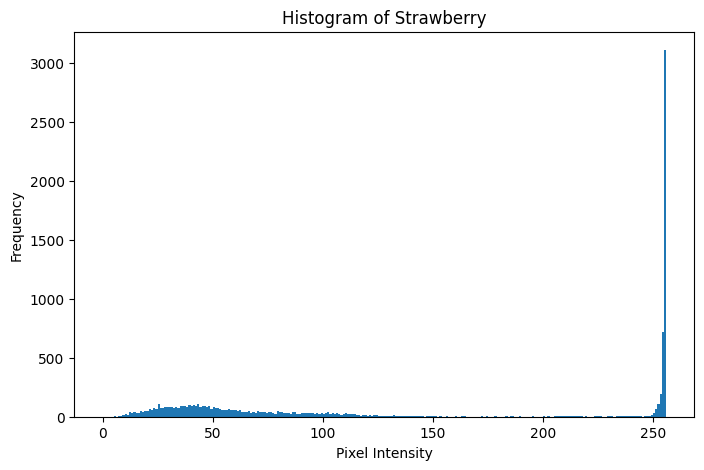

In [34]:
plt.figure(figsize=(8,5))

plt.hist(gray.ravel(), bins=256, range=(0,256))

plt.title("Histogram of Strawberry")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.show()

### Exposure and contrast interpretation

The strawberry is acceptably exposed. Its fruit pixels span dark and mid-range intensities, while the pale background creates a dominant peak close to 255. The broad range provides useful contrast, but the bright peak means a global adjustment can overemphasize the background.


In [35]:
equalized = cv.equalizeHist(gray)

clahe2 = cv.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8,8)
).apply(gray)

clahe8 = cv.createCLAHE(
    clipLimit=8.0,
    tileGridSize=(8,8)
).apply(gray)

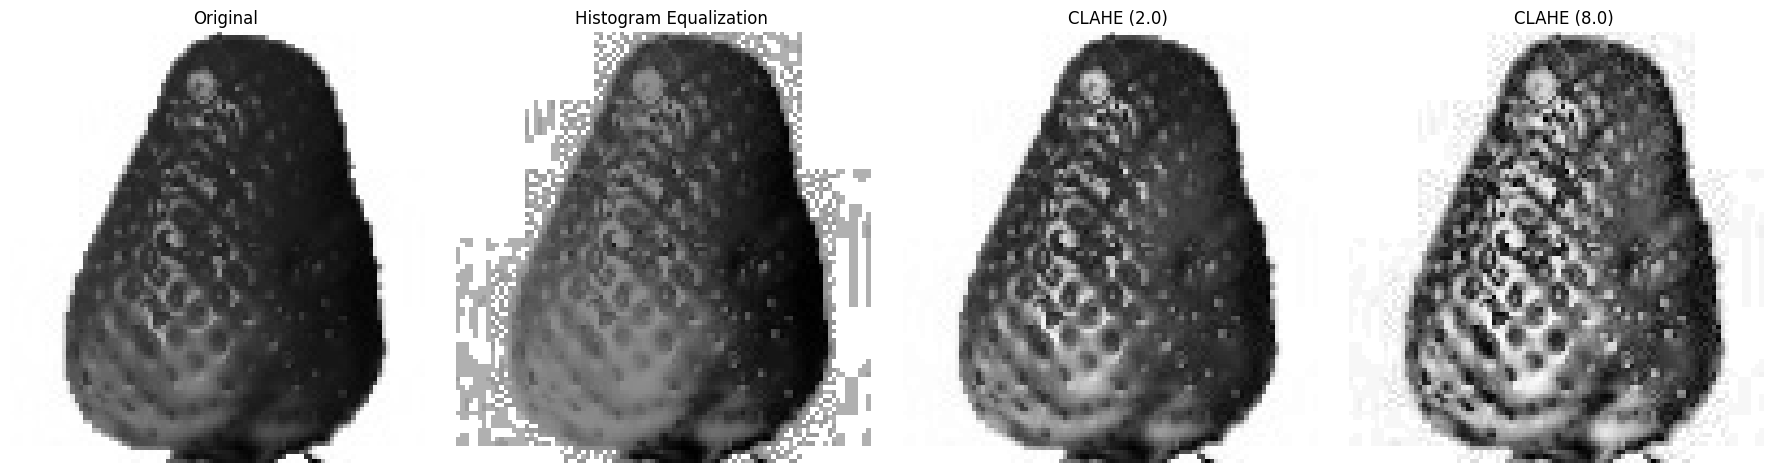

In [36]:
images = [
    gray,
    equalized,
    clahe2,
    clahe8
]

titles = [
    "Original",
    "Histogram Equalization",
    "CLAHE (2.0)",
    "CLAHE (8.0)"
]

plt.figure(figsize=(18,5))

for i in range(4):

    plt.subplot(1,4,i+1)

    plt.imshow(images[i], cmap="gray")

    plt.title(titles[i])

    plt.axis("off")

plt.tight_layout()

plt.show()

### Enhancement comparison

Global equalization boosts contrast across the entire image and can over-brighten the background. CLAHE at 8.0 is more aggressive and may strengthen texture or noise. CLAHE at 2.0 is the best compromise: it raises local fruit contrast without looking excessive, and is the preferred choice when applied to an HSV Value channel before masking.


In [37]:
bgr = cv.imread(ORANGE)

if bgr is None:
    raise FileNotFoundError(ORANGE)

rgb = cv.cvtColor(bgr, cv.COLOR_BGR2RGB)

In [38]:
mean = 0
std = 25

noise = np.random.normal(
    mean,
    std,
    rgb.shape
)

noisy = rgb.astype(np.float32) + noise

noisy = np.clip(noisy,0,255).astype(np.uint8)

In [39]:
gaussian = cv.GaussianBlur(
    noisy,
    (5,5),
    0
)

median = cv.medianBlur(
    noisy,
    5
)

bilateral = cv.bilateralFilter(
    noisy,
    9,
    75,
    75
)

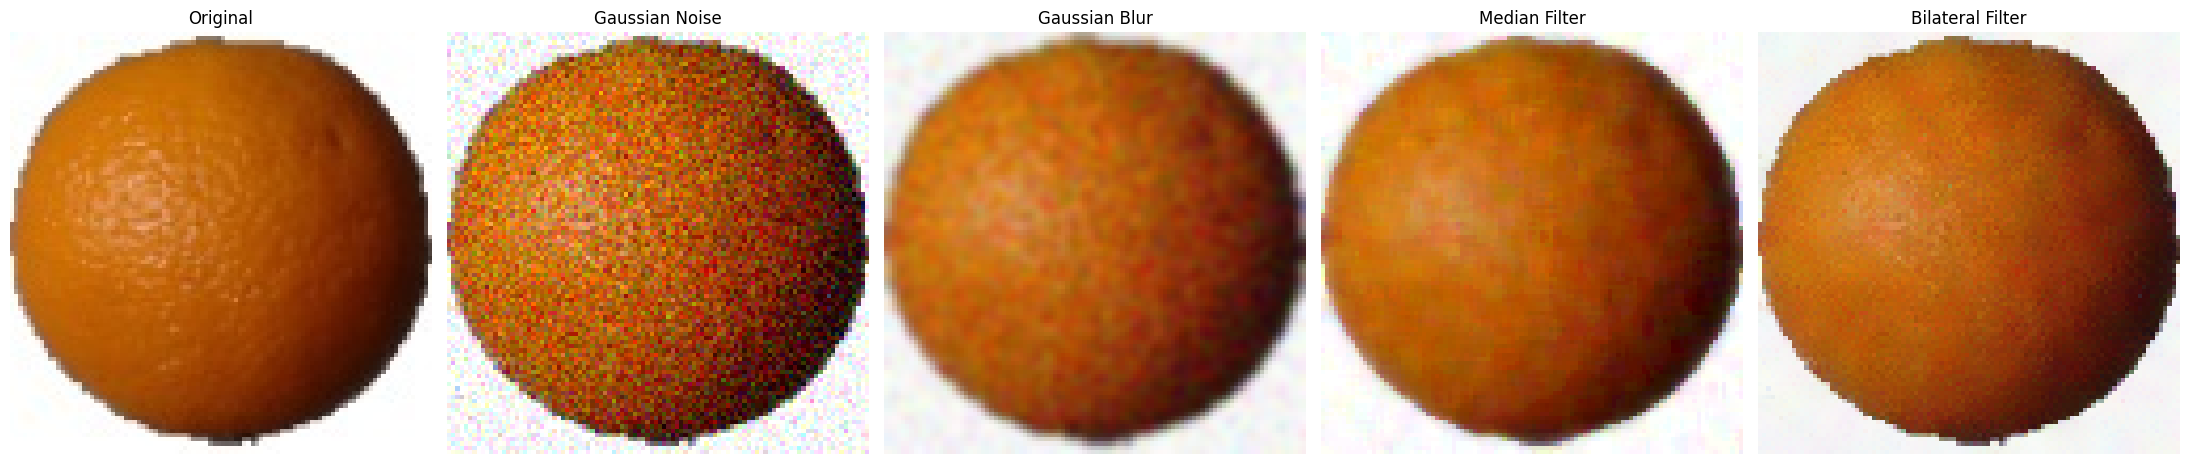

In [40]:
images = [
    rgb,
    noisy,
    gaussian,
    median,
    bilateral
]

titles = [
    "Original",
    "Gaussian Noise",
    "Gaussian Blur",
    "Median Filter",
    "Bilateral Filter"
]

plt.figure(figsize=(22,5))

for i in range(5):

    plt.subplot(1,5,i+1)

    plt.imshow(images[i])

    plt.title(titles[i])

    plt.axis("off")

plt.tight_layout()

plt.show()

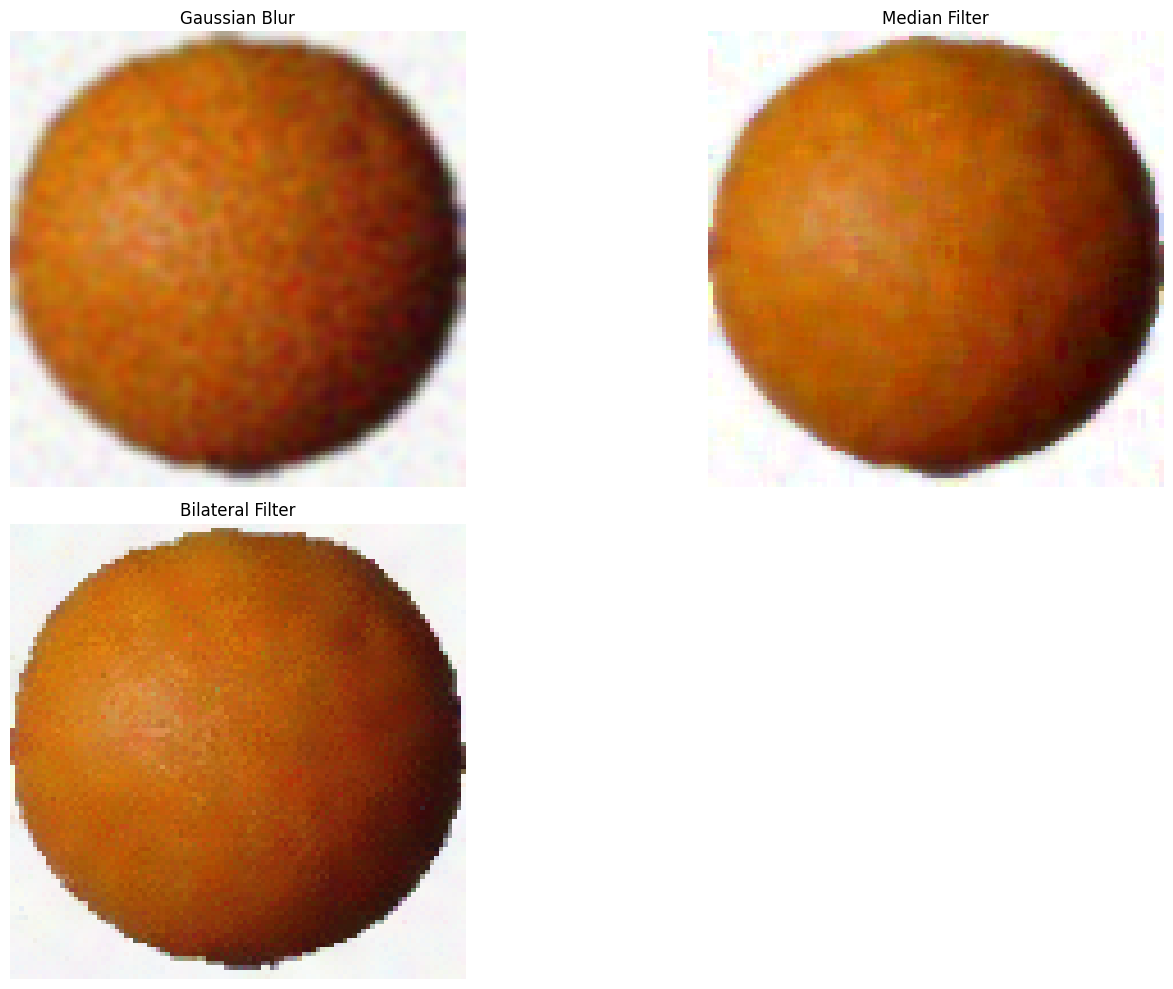

In [41]:
filters = {
    "Gaussian Blur": gaussian,
    "Median Filter": median,
    "Bilateral Filter": bilateral
}

plt.figure(figsize=(15,10))

for i, (name, img) in enumerate(filters.items(), start=1):
    plt.subplot(2,2,i)
    plt.imshow(img)
    plt.title(name)
    plt.axis("off")

plt.tight_layout()
plt.show()

### Filter comparison

Gaussian blur reduces the added Gaussian noise but softens the fruit boundary. Median filtering protects edges better, although it is most useful for impulse noise. The bilateral filter produces the best visual trade-off here because it smooths noisy regions while keeping the orange outline relatively sharp; its main cost is slower computation.


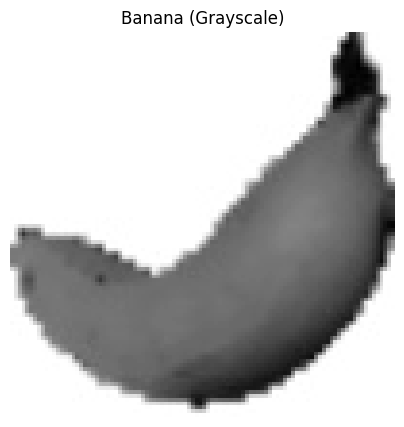

In [42]:
banana_gray = cv.imread(BANANA, cv.IMREAD_GRAYSCALE)

if banana_gray is None:
    raise FileNotFoundError(BANANA)

plt.figure(figsize=(5,5))
plt.imshow(banana_gray, cmap="gray")
plt.title("Banana (Grayscale)")
plt.axis("off")
plt.show()

In [43]:
def conv2d(image, kernel):
    """Apply a 2-D convolution with zero padding and a flipped kernel."""
    image = image.astype(np.float32)
    flipped_kernel = np.flipud(np.fliplr(kernel))
    kernel_height, kernel_width = flipped_kernel.shape
    pad_y, pad_x = kernel_height // 2, kernel_width // 2
    padded_image = np.pad(image, ((pad_y, pad_y), (pad_x, pad_x)), mode="constant")
    output = np.zeros_like(image, dtype=np.float32)

    for row in range(image.shape[0]):
        for col in range(image.shape[1]):
            window = padded_image[row:row + kernel_height, col:col + kernel_width]
            output[row, col] = np.sum(window * flipped_kernel)
    return output


In [44]:
sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

In [45]:
manual = conv2d(banana_gray, sobel_x)

In [46]:
# filter2D performs correlation, so flip the Sobel kernel to compare it with conv2d.
opencv = cv.filter2D(
    banana_gray.astype(np.float32),
    -1,
    np.flipud(np.fliplr(sobel_x)),
    borderType=cv.BORDER_CONSTANT,
)


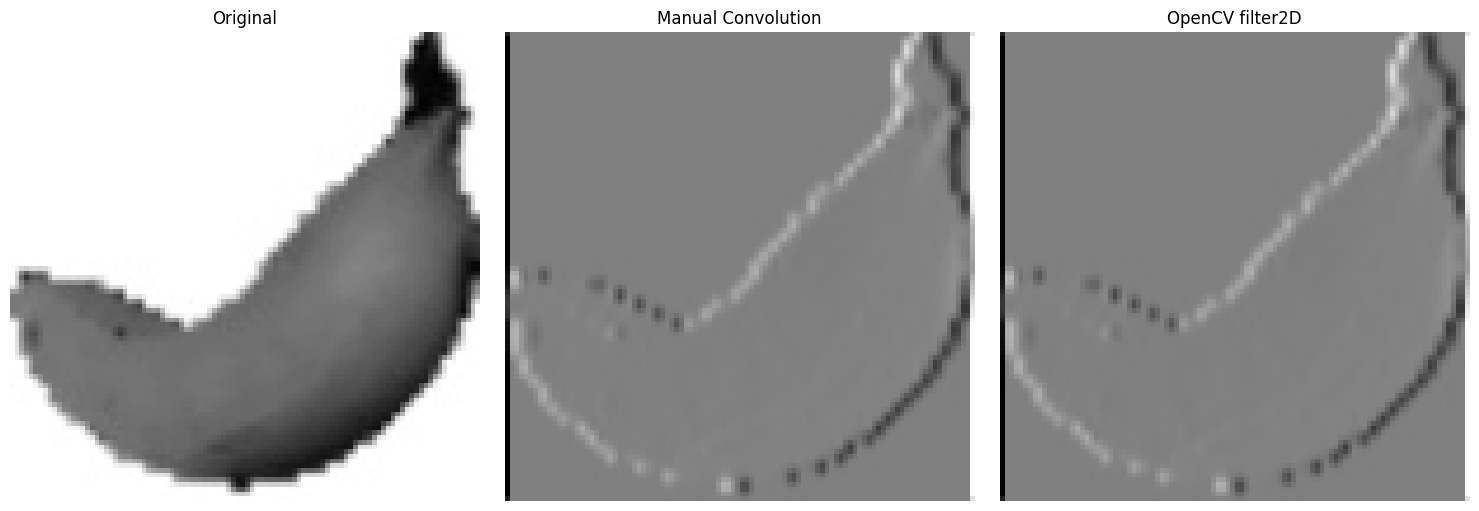

In [47]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(banana_gray, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(manual, cmap="gray")
plt.title("Manual Convolution")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(opencv, cmap="gray")
plt.title("OpenCV filter2D")
plt.axis("off")

plt.tight_layout()
plt.show()

In [51]:
mad = np.mean(np.abs(manual - opencv))

print(f"Mean Absolute Difference = {mad:.4f}")

Mean Absolute Difference = 0.0000


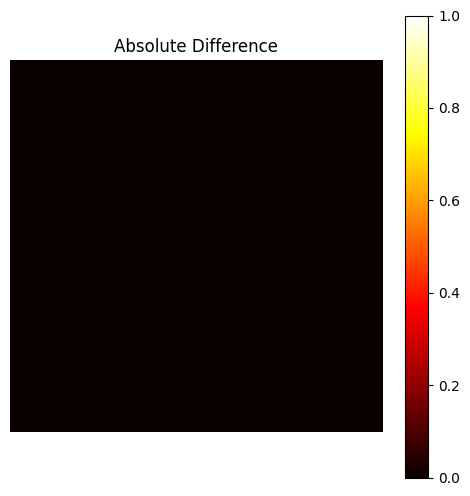

In [52]:
difference = np.abs(manual - opencv)

plt.figure(figsize=(6,6))
plt.imshow(difference, cmap="hot", vmin=0, vmax=1)
plt.title("Absolute Difference")
plt.colorbar()
plt.axis("off")
plt.show()

### Convolution comparison

The two outputs use identical padding and kernel conventions. The hand-written routine performs true convolution by flipping the kernel, while cv.filter2D performs correlation, so the OpenCV kernel is flipped before comparison. This alignment should make the MAD zero or very close to zero, with only minor floating-point variation.


# Part C — Morphological Mask Cleanup

Colour masks often include isolated pixels, small gaps, and shadow-related holes. This part applies binary morphology to improve the banana mask before boundary or contour analysis.


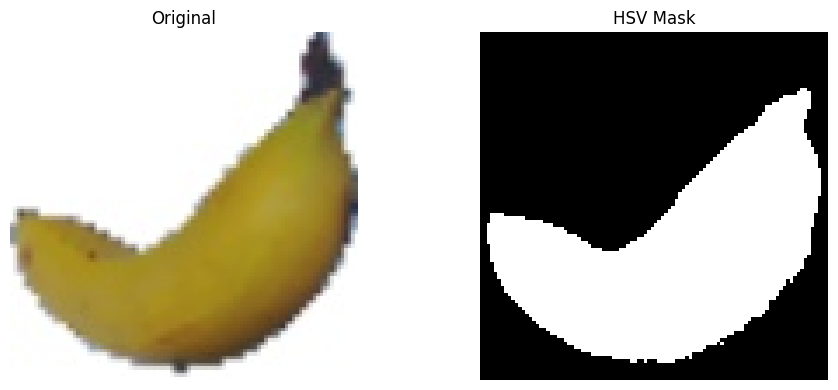

In [53]:
banana_bgr = cv.imread(BANANA)

if banana_bgr is None:
    raise FileNotFoundError(BANANA)

banana_rgb = cv.cvtColor(banana_bgr, cv.COLOR_BGR2RGB)
banana_hsv = cv.cvtColor(banana_bgr, cv.COLOR_BGR2HSV)

# HSV range for banana (adjust if necessary)
lower = np.array([15, 80, 80])
upper = np.array([40, 255, 255])

mask = cv.inRange(banana_hsv, lower, upper)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(banana_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("HSV Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

In [54]:
kernel = np.ones((5,5), np.uint8)

erosion = cv.erode(
    mask,
    kernel,
    iterations=1
)

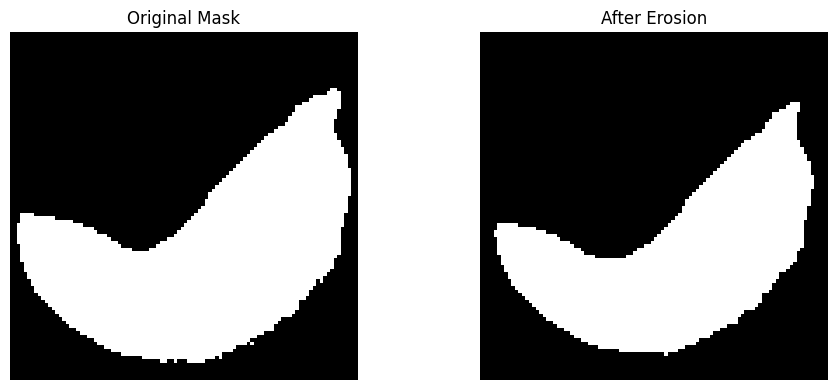

In [55]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(mask, cmap="gray")
plt.title("Original Mask")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(erosion, cmap="gray")
plt.title("After Erosion")
plt.axis("off")

plt.tight_layout()
plt.show()

### Erosion result

Erosion contracts the white foreground area. It removes small isolated regions, but it also narrows delicate parts of the banana, so repeated erosion can discard useful shape information.


In [56]:
opening = cv.morphologyEx(
    mask,
    cv.MORPH_OPEN,
    kernel
)

In [57]:
closing = cv.morphologyEx(
    mask,
    cv.MORPH_CLOSE,
    kernel
)

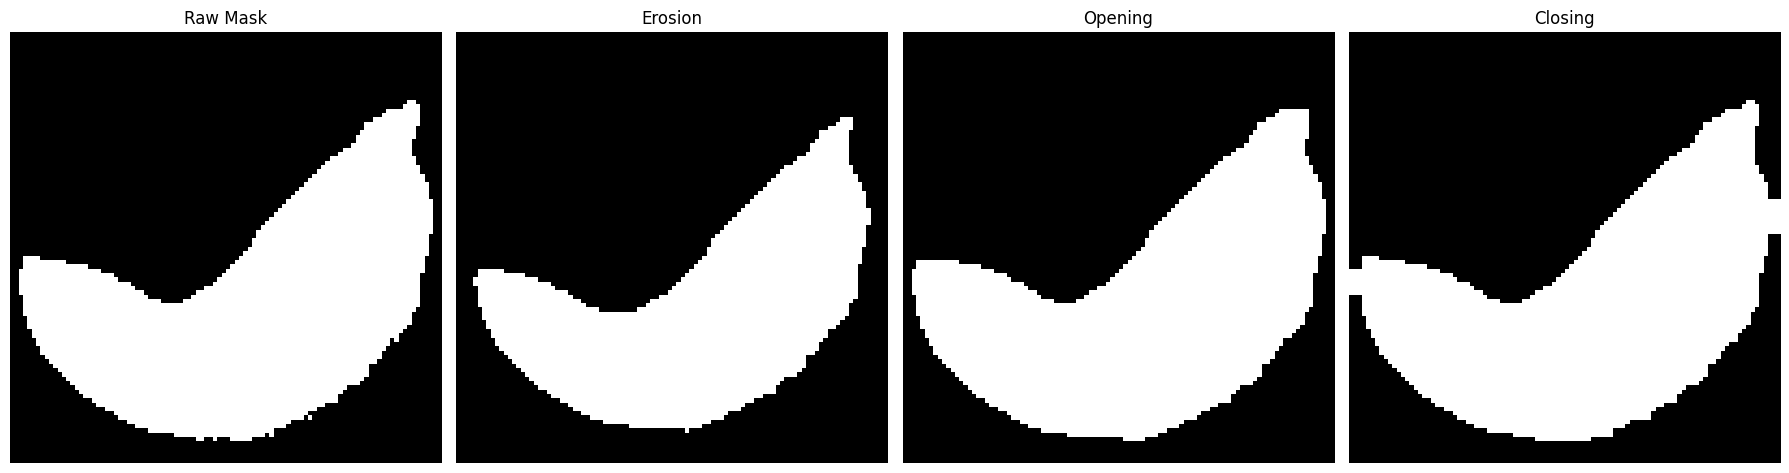

In [58]:
images = [
    mask,
    erosion,
    opening,
    closing
]

titles = [
    "Raw Mask",
    "Erosion",
    "Opening",
    "Closing"
]

plt.figure(figsize=(18,5))

for i in range(4):

    plt.subplot(1,4,i+1)

    plt.imshow(images[i], cmap="gray")

    plt.title(titles[i])

    plt.axis("off")

plt.tight_layout()
plt.show()

### Mask-cleaning comparison

The raw mask contains the initial banana segmentation. Erosion removes tiny foreground fragments but shrinks the object. Opening removes small noise with less damage to the main shape, while closing reconnects gaps and fills small holes. For later contour measurements, the closed mask is normally the most continuous representation.


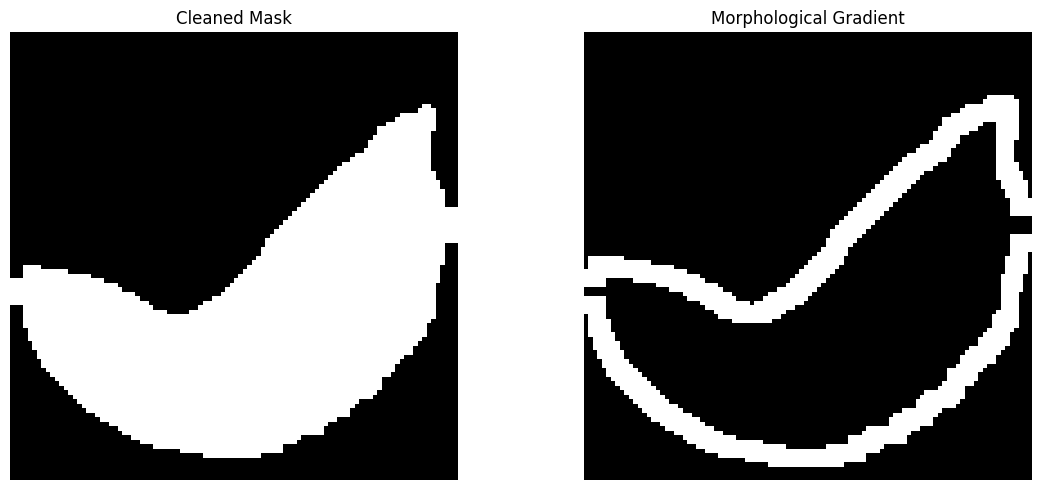

In [59]:
gradient = cv.morphologyEx(
    closing,
    cv.MORPH_GRADIENT,
    kernel
)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(closing, cmap="gray")
plt.title("Cleaned Mask")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(gradient, cmap="gray")
plt.title("Morphological Gradient")
plt.axis("off")

plt.tight_layout()
plt.show()

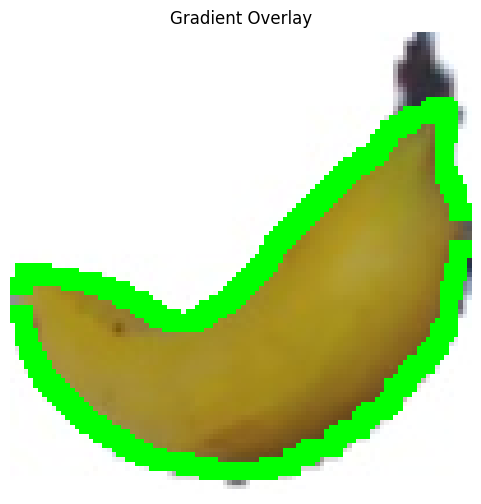

In [60]:
overlay = banana_rgb.copy()

overlay[gradient > 0] = [0,255,0]

plt.figure(figsize=(6,6))
plt.imshow(overlay)
plt.title("Gradient Overlay")
plt.axis("off")
plt.show()

### Gradient overlay

The morphological gradient retains pixels near the cleaned mask boundary. Replacing those locations with green on the RGB image makes the banana contour visible without replacing the original image content.


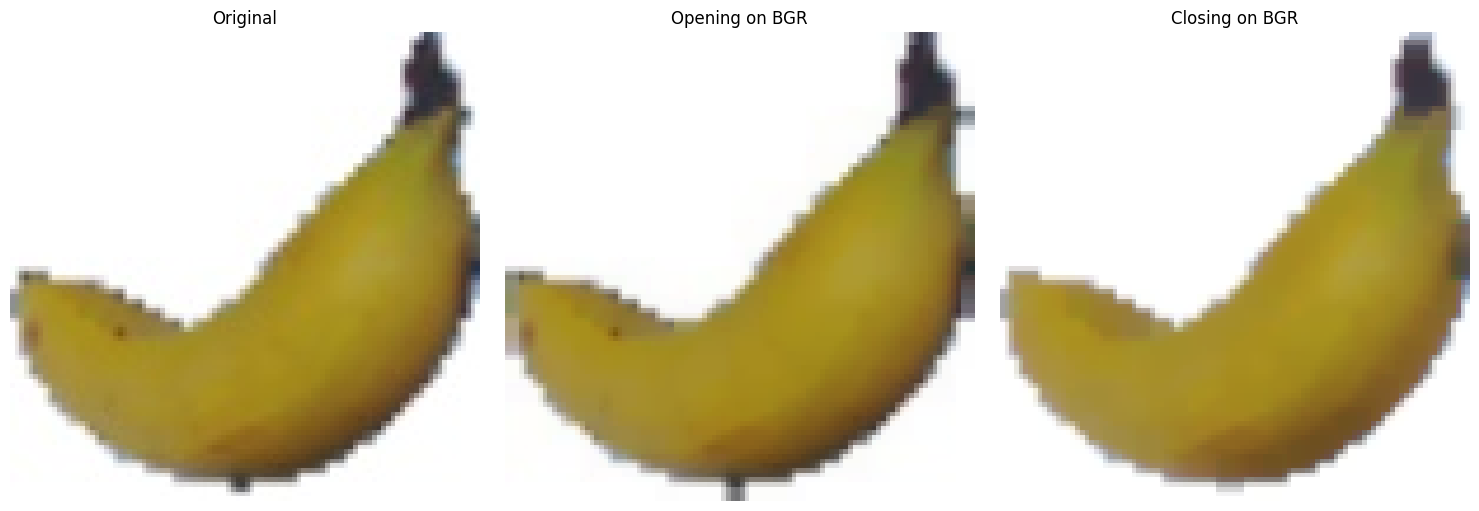

In [61]:
bgr_open = cv.morphologyEx(
    banana_bgr,
    cv.MORPH_OPEN,
    kernel
)

bgr_close = cv.morphologyEx(
    banana_bgr,
    cv.MORPH_CLOSE,
    kernel
)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(cv.cvtColor(banana_bgr, cv.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(cv.cvtColor(bgr_open, cv.COLOR_BGR2RGB))
plt.title("Opening on BGR")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(cv.cvtColor(bgr_close, cv.COLOR_BGR2RGB))
plt.title("Closing on BGR")
plt.axis("off")

plt.tight_layout()
plt.show()

### Reflection

Morphology is most meaningful on a binary or single-channel mask. Applying it directly to a BGR image changes channel intensities independently, which creates colour artifacts instead of cleaning a selected object. Segmentation should therefore come before morphological processing.


In [62]:
from google.colab import files

uploaded = files.upload()
MORPH_IMG = next(
    (name for name in uploaded if "morphology" in name.lower()),
    None,
)
if MORPH_IMG is None:
    raise FileNotFoundError("Please upload morphology.png.")


Saving morphology.png to morphology.png


In [63]:
img = cv.imread(MORPH_IMG, cv.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError(f"Could not open {MORPH_IMG}.")

_, binary = cv.threshold(img, 127, 255, cv.THRESH_BINARY)
print(f"Processed: {MORPH_IMG}")


Processed: morphology.png


In [64]:
kernel = np.ones((5,5), np.uint8)

erosion = cv.erode(binary, kernel)

dilation = cv.dilate(binary, kernel)

opening = cv.morphologyEx(binary, cv.MORPH_OPEN, kernel)

closing = cv.morphologyEx(binary, cv.MORPH_CLOSE, kernel)

tophat = cv.morphologyEx(binary, cv.MORPH_TOPHAT, kernel)

blackhat = cv.morphologyEx(binary, cv.MORPH_BLACKHAT, kernel)

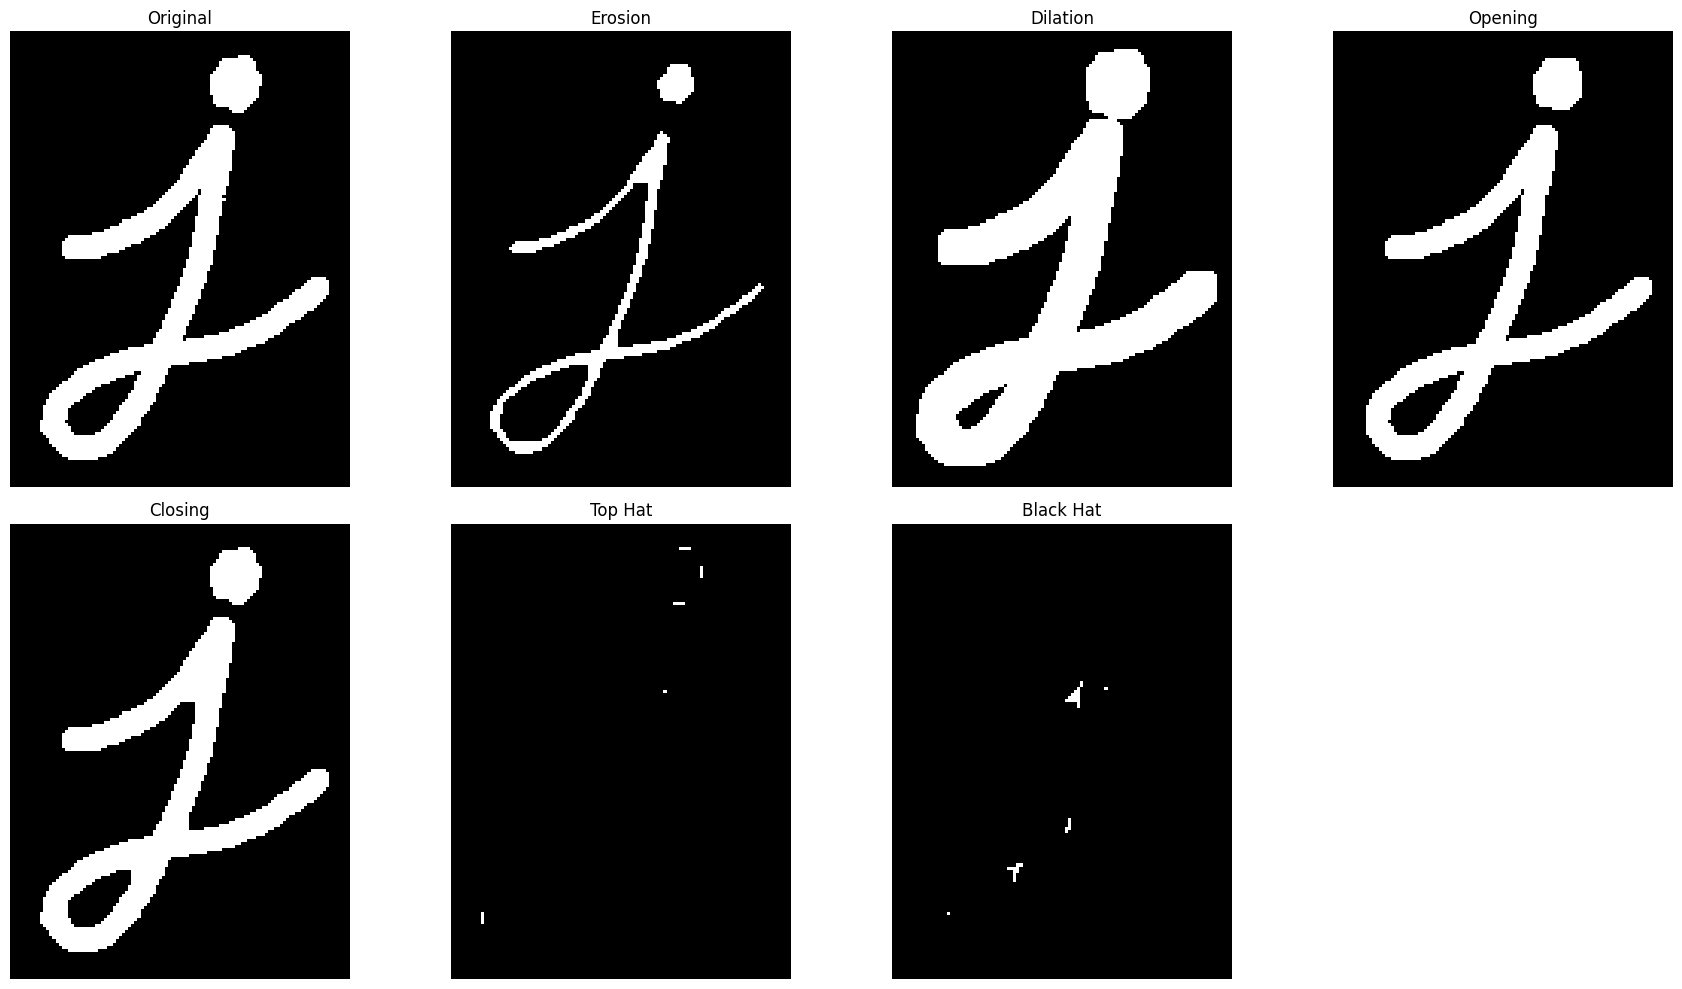

In [65]:
images = [
    binary,
    erosion,
    dilation,
    opening,
    closing,
    tophat,
    blackhat
]

titles = [
    "Original",
    "Erosion",
    "Dilation",
    "Opening",
    "Closing",
    "Top Hat",
    "Black Hat"
]

plt.figure(figsize=(18,10))

for i in range(len(images)):

    plt.subplot(2,4,i+1)

    plt.imshow(images[i], cmap="gray")

    plt.title(titles[i])

    plt.axis("off")

plt.tight_layout()

plt.show()

### Morphology operations

Erosion reduces bright foreground regions, whereas dilation expands them. Opening is useful for suppressing small bright noise and closing repairs small dark gaps. Top Hat returns small bright details removed by opening; Black Hat returns small dark details removed by closing.


### Thin-stroke result

Top Hat most clearly isolates thin bright strokes because it subtracts the opened image from the original. If the strokes were dark on a bright field, Black Hat would be the more appropriate choice.


# Part D — Shape and Feature Detection

This part evaluates edge detection, manually implemented Canny stages, Harris corners, circle detection, and a complete colour-to-bounding-box pipeline.


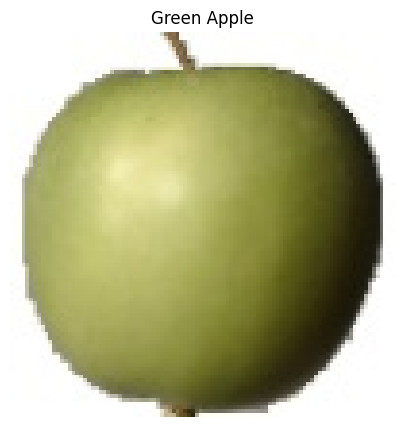

In [66]:
green_bgr = cv.imread(GREEN_APPLE)

if green_bgr is None:
    raise FileNotFoundError(GREEN_APPLE)

green_rgb = cv.cvtColor(green_bgr, cv.COLOR_BGR2RGB)

green_gray = cv.cvtColor(green_bgr, cv.COLOR_BGR2GRAY)

plt.figure(figsize=(5,5))
plt.imshow(green_rgb)
plt.title("Green Apple")
plt.axis("off")
plt.show()

In [67]:
edges_low = cv.Canny(
    green_gray,
    30,
    100
)

edges_high = cv.Canny(
    green_gray,
    100,
    200
)

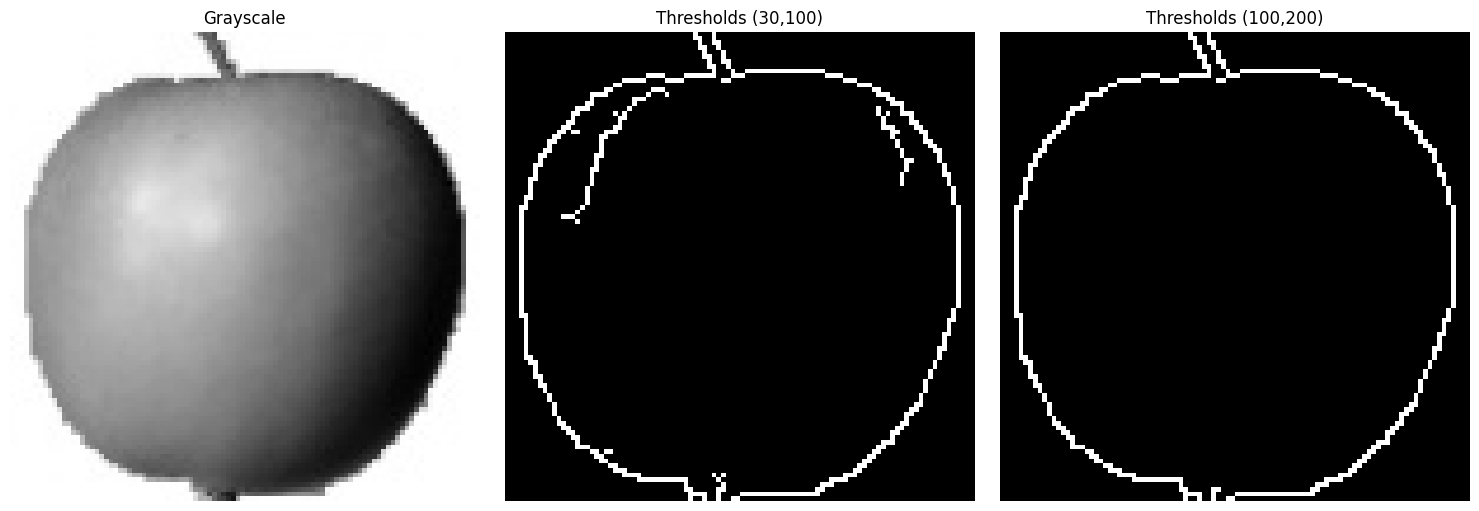

In [68]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(green_gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(edges_low, cmap="gray")
plt.title("Thresholds (30,100)")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(edges_high, cmap="gray")
plt.title("Thresholds (100,200)")
plt.axis("off")

plt.tight_layout()
plt.show()

### Canny threshold comparison

The 30/100 thresholds retain weak texture edges as well as the fruit boundary. With 100/200, only stronger gradients survive, producing a less cluttered outline. The higher pair is therefore the cleaner choice for this image.


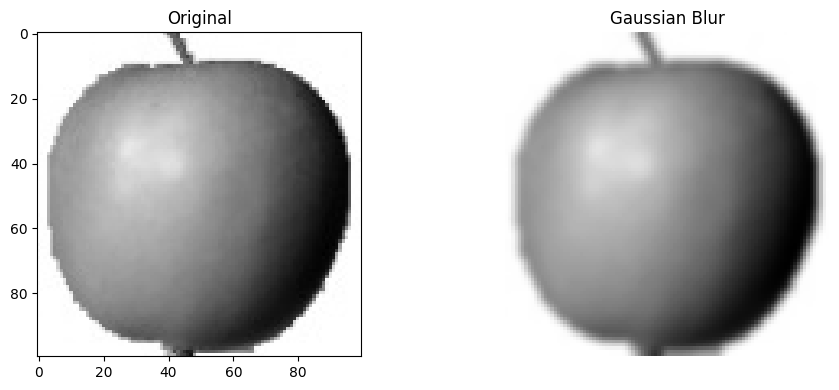

In [69]:
blur = cv.GaussianBlur(
    green_gray,
    (5,5),
    1.4
)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(green_gray, cmap="gray")
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(blur, cmap="gray")
plt.title("Gaussian Blur")

plt.axis("off")
plt.tight_layout()
plt.show()

In [70]:
grad_x = cv.Sobel(
    blur,
    cv.CV_64F,
    1,
    0,
    ksize=3
)

grad_y = cv.Sobel(
    blur,
    cv.CV_64F,
    0,
    1,
    ksize=3
)

magnitude = cv.magnitude(grad_x, grad_y)

direction = np.arctan2(grad_y, grad_x)

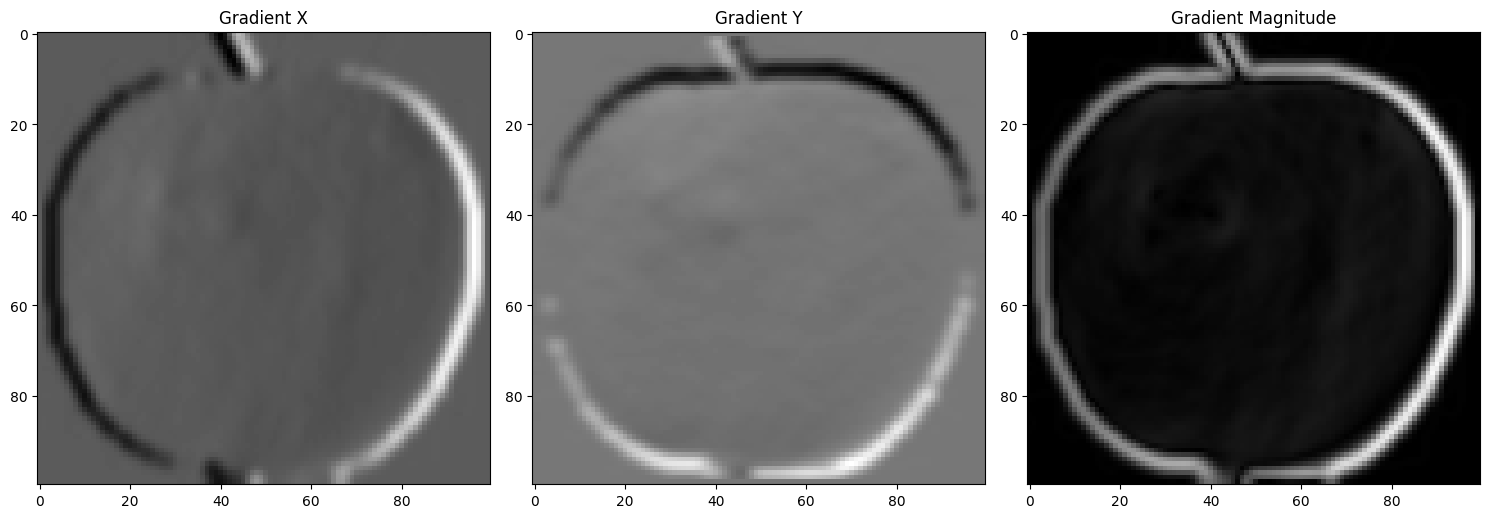

In [71]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(grad_x, cmap="gray")
plt.title("Gradient X")

plt.subplot(1,3,2)
plt.imshow(grad_y, cmap="gray")
plt.title("Gradient Y")

plt.subplot(1,3,3)
plt.imshow(magnitude, cmap="gray")
plt.title("Gradient Magnitude")

plt.tight_layout()
plt.show()

## Canny interpretation

Canny first smooths noise, computes intensity gradients, thins candidate edges with non-maximum suppression, then uses two thresholds and hysteresis to keep connected strong boundaries. Raising either threshold rejects more weak gradients; that reduces noise but can also remove faint object edges. For this apple, 100/200 gives the best boundary/noise balance.


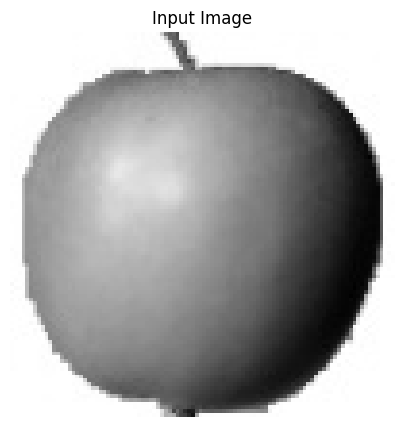

In [72]:
image = cv.imread(GREEN_APPLE)

if image is None:
    raise FileNotFoundError(GREEN_APPLE)

gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)

plt.figure(figsize=(5,5))
plt.imshow(gray, cmap="gray")
plt.title("Input Image")
plt.axis("off")
plt.show()

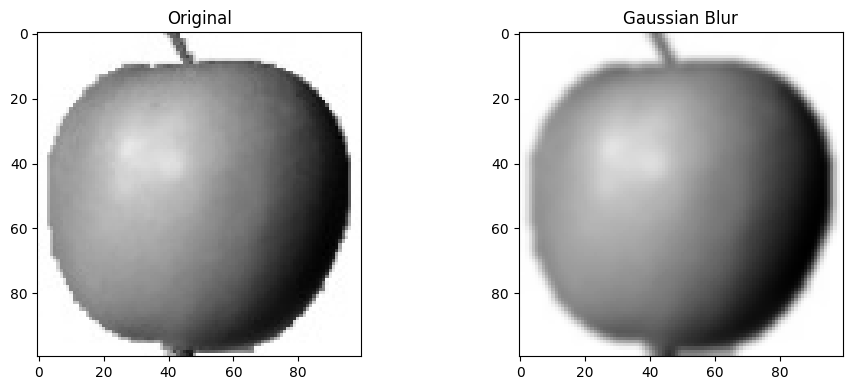

In [73]:
blur = cv.GaussianBlur(
    gray,
    (5,5),
    sigmaX=1.4
)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(gray, cmap="gray")
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(blur, cmap="gray")
plt.title("Gaussian Blur")

plt.tight_layout()
plt.show()

In [74]:
gx = cv.Sobel(
    blur,
    cv.CV_64F,
    1,
    0,
    ksize=3
)

gy = cv.Sobel(
    blur,
    cv.CV_64F,
    0,
    1,
    ksize=3
)

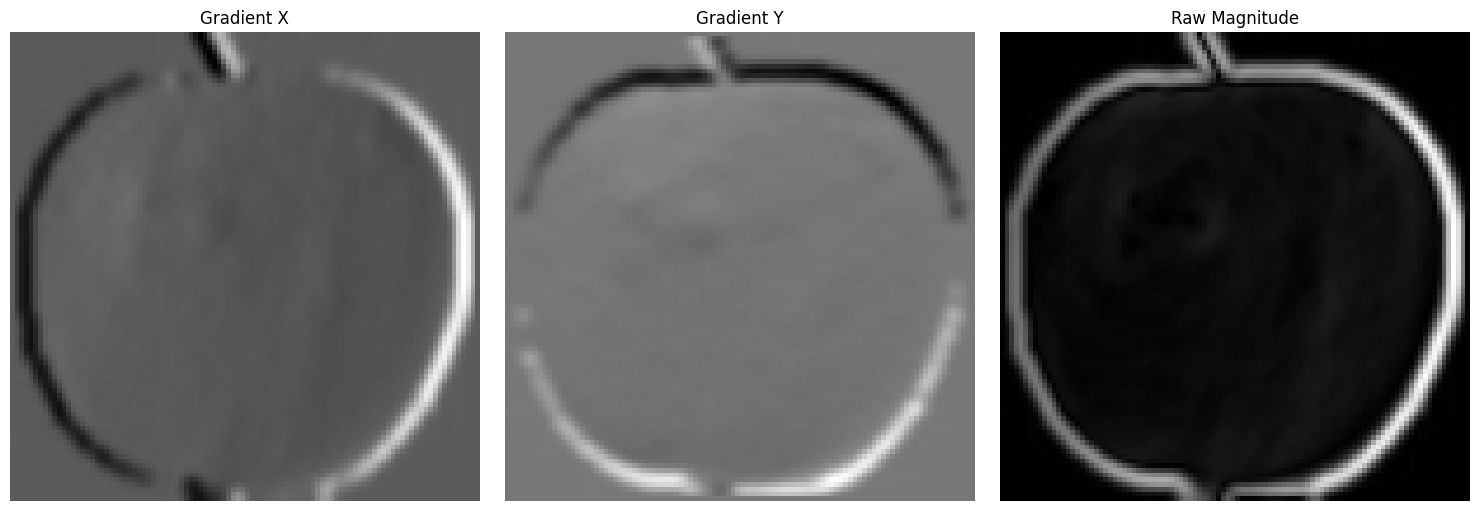

In [75]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(gx, cmap="gray")
plt.title("Gradient X")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(gy, cmap="gray")
plt.title("Gradient Y")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(np.sqrt(gx**2 + gy**2), cmap="gray")
plt.title("Raw Magnitude")
plt.axis("off")

plt.tight_layout()
plt.show()

In [76]:
magnitude = np.hypot(gx, gy)

magnitude = magnitude / magnitude.max() * 255

direction = np.arctan2(gy, gx)

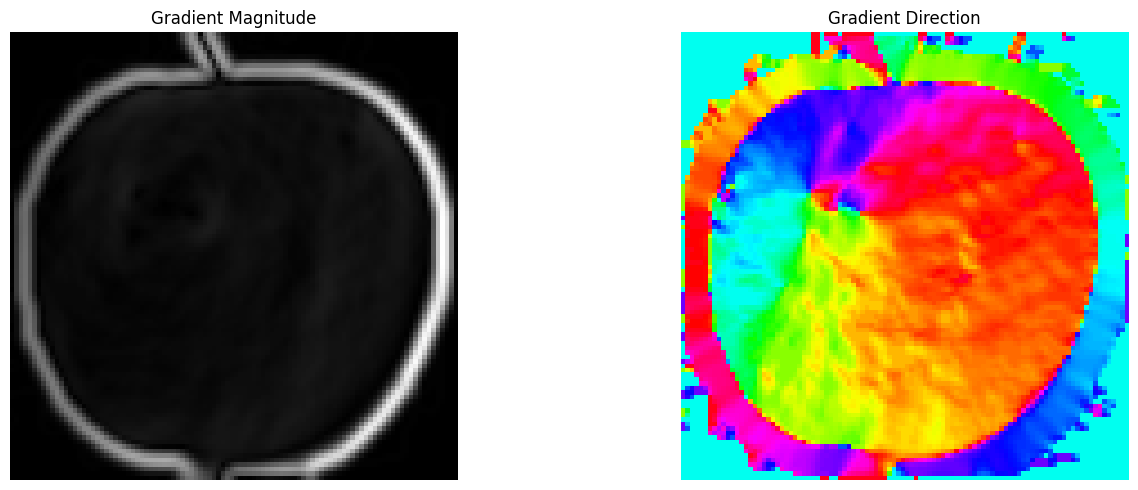

In [77]:
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)

plt.imshow(magnitude, cmap="gray")

plt.title("Gradient Magnitude")

plt.axis("off")

plt.subplot(1,2,2)

plt.imshow(direction, cmap="hsv")

plt.title("Gradient Direction")

plt.axis("off")

plt.tight_layout()

plt.show()

In [78]:
class CannyEdgeDetector:
    """Canny edge detector implemented as individual processing stages."""

    def __init__(self, low_threshold=50, high_threshold=150):
        self.low, self.high = low_threshold, high_threshold
        self.weak, self.strong = 75, 255

    def non_maximum_suppression(self, magnitude, direction):
        output = np.zeros_like(magnitude, dtype=np.float32)
        angle = np.rad2deg(direction) % 180
        rows, cols = magnitude.shape
        for row in range(1, rows - 1):
            for col in range(1, cols - 1):
                if angle[row, col] < 22.5 or angle[row, col] >= 157.5:
                    first, second = magnitude[row, col - 1], magnitude[row, col + 1]
                elif angle[row, col] < 67.5:
                    first, second = magnitude[row - 1, col + 1], magnitude[row + 1, col - 1]
                elif angle[row, col] < 112.5:
                    first, second = magnitude[row - 1, col], magnitude[row + 1, col]
                else:
                    first, second = magnitude[row - 1, col - 1], magnitude[row + 1, col + 1]
                if magnitude[row, col] >= first and magnitude[row, col] >= second:
                    output[row, col] = magnitude[row, col]
        return output

    def double_threshold(self, image):
        output = np.zeros_like(image, dtype=np.uint8)
        output[image >= self.high] = self.strong
        output[(image >= self.low) & (image < self.high)] = self.weak
        return output

    def hysteresis(self, image):
        output = image.copy()
        changed = True
        while changed:
            changed = False
            for row, col in np.argwhere(output == self.weak):
                if np.any(output[max(0, row - 1):row + 2, max(0, col - 1):col + 2] == self.strong):
                    output[row, col] = self.strong
                    changed = True
        output[output != self.strong] = 0
        return output

    def detect(self, gray_image):
        blurred = cv.GaussianBlur(gray_image, (5, 5), 1.4)
        grad_x = cv.Sobel(blurred, cv.CV_64F, 1, 0, ksize=3)
        grad_y = cv.Sobel(blurred, cv.CV_64F, 0, 1, ksize=3)
        magnitude = np.hypot(grad_x, grad_y)
        magnitude = magnitude / magnitude.max() * 255 if magnitude.max() else magnitude
        nms = self.non_maximum_suppression(magnitude, np.arctan2(grad_y, grad_x))
        thresholded = self.double_threshold(nms)
        return blurred, magnitude, nms, thresholded, self.hysteresis(thresholded)


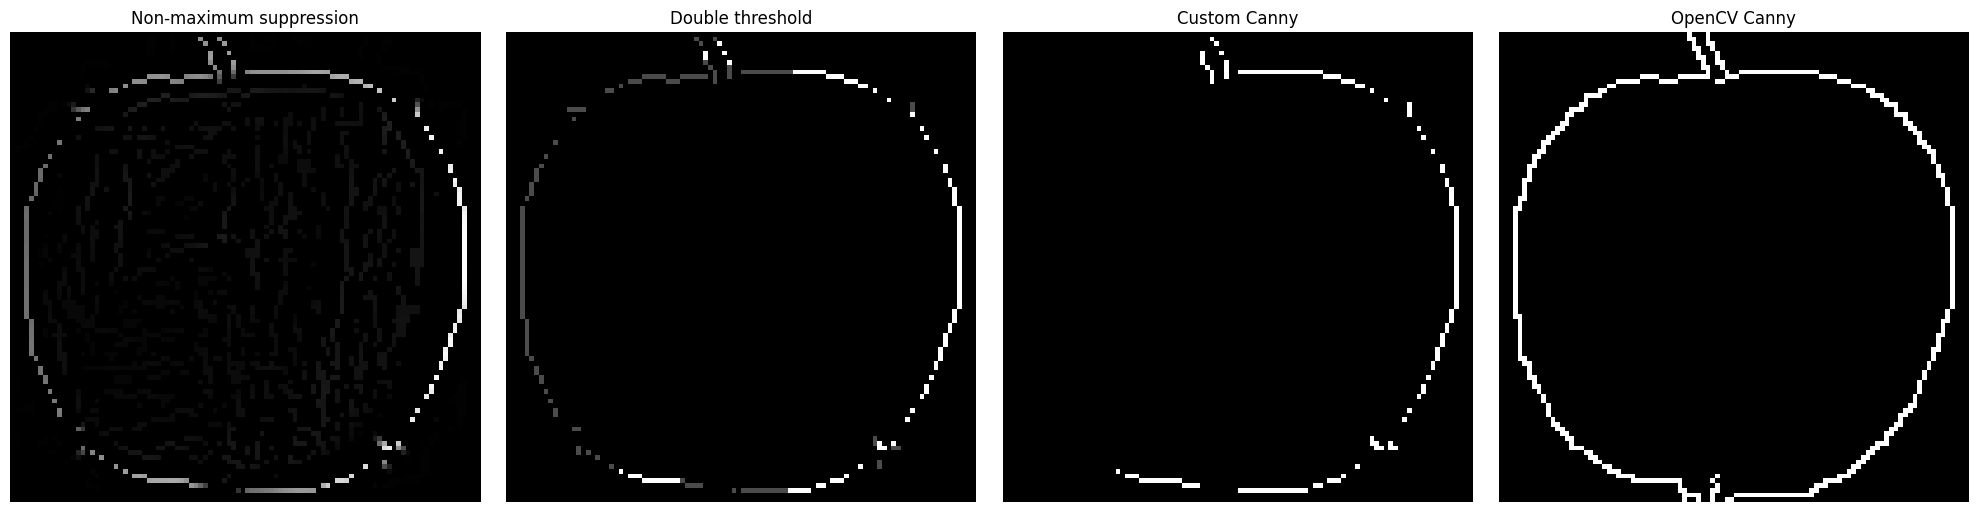

Custom-vs-OpenCV Canny MAD: 7.37


In [79]:
detector = CannyEdgeDetector(low_threshold=50, high_threshold=150)
blurred, custom_magnitude, nms, thresholded, custom_edges = detector.detect(green_gray)
opencv_edges = cv.Canny(green_gray, 50, 150)
mad_canny = np.mean(np.abs(custom_edges.astype(np.float32) - opencv_edges.astype(np.float32)))

show_many(
    [nms, thresholded, custom_edges, opencv_edges],
    ["Non-maximum suppression", "Double threshold", "Custom Canny", "OpenCV Canny"],
    cmap="gray",
)
print(f"Custom-vs-OpenCV Canny MAD: {mad_canny:.2f}")


### Custom Canny comparison

The custom detector performs Gaussian smoothing, Sobel gradients, non-maximum suppression, double thresholding, and hysteresis. Its final edge map is compared with OpenCV Canny using mean absolute difference. A small mismatch is normal because library implementations use different scaling and edge-tracking details.


## Canny conclusion

The custom result follows the same overall pipeline as OpenCV and provides visibility into each intermediate stage. Any remaining MAD reflects implementation choices rather than a missing Canny step.


In [80]:
from google.colab import files

uploaded = files.upload()
CHESSBOARD_IMG = next(
    (name for name in uploaded if "chessboard" in name.lower()),
    None,
)
if CHESSBOARD_IMG is None:
    raise FileNotFoundError("Please upload chessboard.png.")


Saving chessboard.png to chessboard.png


In [81]:
chess_bgr = cv.imread(CHESSBOARD_IMG)
if chess_bgr is None:
    raise FileNotFoundError(CHESSBOARD_IMG)

chess_rgb = cv.cvtColor(chess_bgr, cv.COLOR_BGR2RGB)
chess_gray = cv.cvtColor(chess_bgr, cv.COLOR_BGR2GRAY).astype(np.float32)
corner_response = cv.dilate(
    cv.cornerHarris(chess_gray, blockSize=2, ksize=3, k=0.04),
    None,
)


### Harris corner setup

The chessboard is a useful Harris test image because its grid intersections create strong, repeatable two-direction intensity changes.


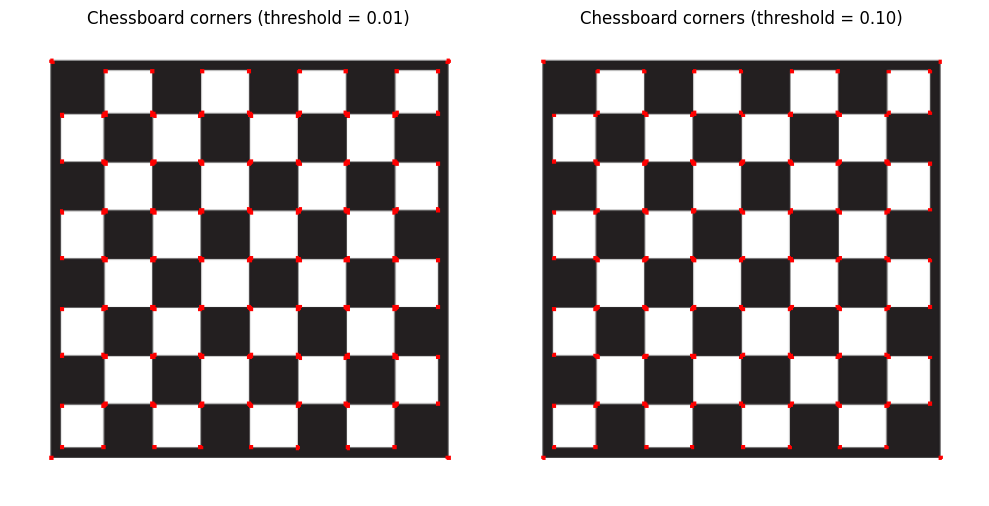

In [82]:
corners_001 = chess_rgb.copy()
corners_010 = chess_rgb.copy()
corners_001[corner_response > 0.01 * corner_response.max()] = [255, 0, 0]
corners_010[corner_response > 0.10 * corner_response.max()] = [255, 0, 0]

show_many(
    [corners_001, corners_010],
    ["Chessboard corners (threshold = 0.01)", "Chessboard corners (threshold = 0.10)"],
)


### Harris threshold comparison

At 0.01 of the maximum response, many points qualify as corners, including weaker responses. At 0.10, the threshold keeps only the most prominent intersections, reducing the number of marked points and potential false detections.


In [83]:
from google.colab import files

uploaded = files.upload()
MIXED_BOWL_IMG = next(
    (name for name in uploaded if "mixed_fruit_bowl" in name.lower()),
    None,
)
if MIXED_BOWL_IMG is None:
    raise FileNotFoundError("Please upload mixed_fruit_bowl.jpeg.")


Saving mixed_fruit_bowl.jpeg to mixed_fruit_bowl.jpeg


In [84]:
img = cv.imread(MIXED_BOWL_IMG)
if img is None:
    raise FileNotFoundError(MIXED_BOWL_IMG)

rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
gray = cv.medianBlur(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 5)


In [85]:
# Work at half resolution so the required 30--100 pixel radius range fits the fruits.
scale = 0.5
circle_input = cv.resize(img, None, fx=scale, fy=scale, interpolation=cv.INTER_AREA)
circle_gray = cv.medianBlur(cv.cvtColor(circle_input, cv.COLOR_BGR2GRAY), 5)

circles = cv.HoughCircles(
    circle_gray,
    cv.HOUGH_GRADIENT,
    dp=1.2,
    minDist=120,
    param1=120,
    param2=35,
    minRadius=30,
    maxRadius=100,
)


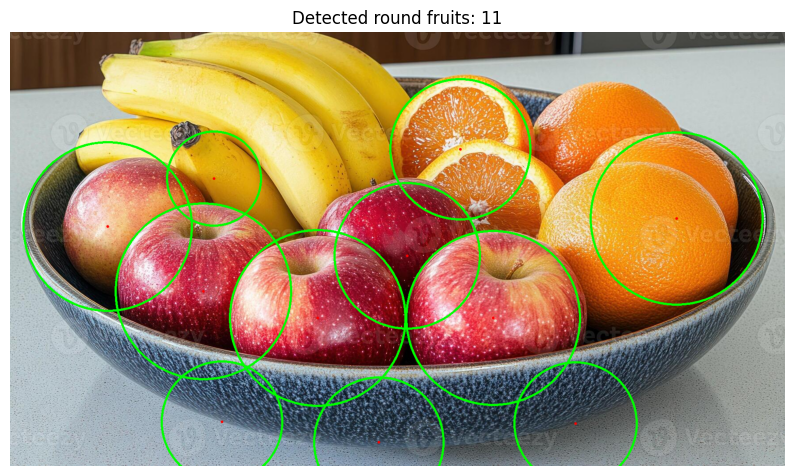

Detected round fruits after tuning: 11


In [86]:
output = rgb.copy()
count = 0

if circles is not None:
    circles = np.round(circles[0]).astype(int)
    count = len(circles)

    for center_x, center_y, radius in circles:
        # Convert detections back to the original image coordinates for drawing.
        x = int(center_x / scale)
        y = int(center_y / scale)
        r = int(radius / scale)
        cv.circle(output, (x, y), r, (0, 255, 0), 3)
        cv.circle(output, (x, y), 3, (255, 0, 0), -1)

plt.figure(figsize=(10, 6))
plt.imshow(output)
plt.title(f"Detected round fruits: {count}")
plt.axis("off")
plt.show()
print(f"Detected round fruits after tuning: {count}")


### Hough-circle result

Detection is performed at half resolution so the required 30–100 pixel radius interval fits the fruit scale. A stricter accumulator threshold and a larger centre separation reduce duplicate detections. The printed count is the final detector result; compare the plotted circles with the visible round fruit to judge whether any are missed or repeated.


In [87]:
# Final deliverable: isolate red apples in the supplied mixed bowl.
image_path = MIXED_BOWL_IMG
bgr = cv.imread(image_path)
if bgr is None:
    raise FileNotFoundError(image_path)

rgb = cv.cvtColor(bgr, cv.COLOR_BGR2RGB)
hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)


In [88]:
# Red wraps around OpenCV's hue interval, so combine two red masks.
lower_red_a, upper_red_a = np.array([0, 85, 45]), np.array([10, 255, 255])
lower_red_b, upper_red_b = np.array([170, 85, 45]), np.array([180, 255, 255])
raw_mask = cv.bitwise_or(
    cv.inRange(hsv, lower_red_a, upper_red_a),
    cv.inRange(hsv, lower_red_b, upper_red_b),
)
segmented = cv.bitwise_and(rgb, rgb, mask=raw_mask)


In [89]:
kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (7, 7))
opened_mask = cv.morphologyEx(raw_mask, cv.MORPH_OPEN, kernel)
clean_mask = cv.morphologyEx(opened_mask, cv.MORPH_CLOSE, kernel, iterations=2)
edges = cv.Canny(clean_mask, 50, 150)


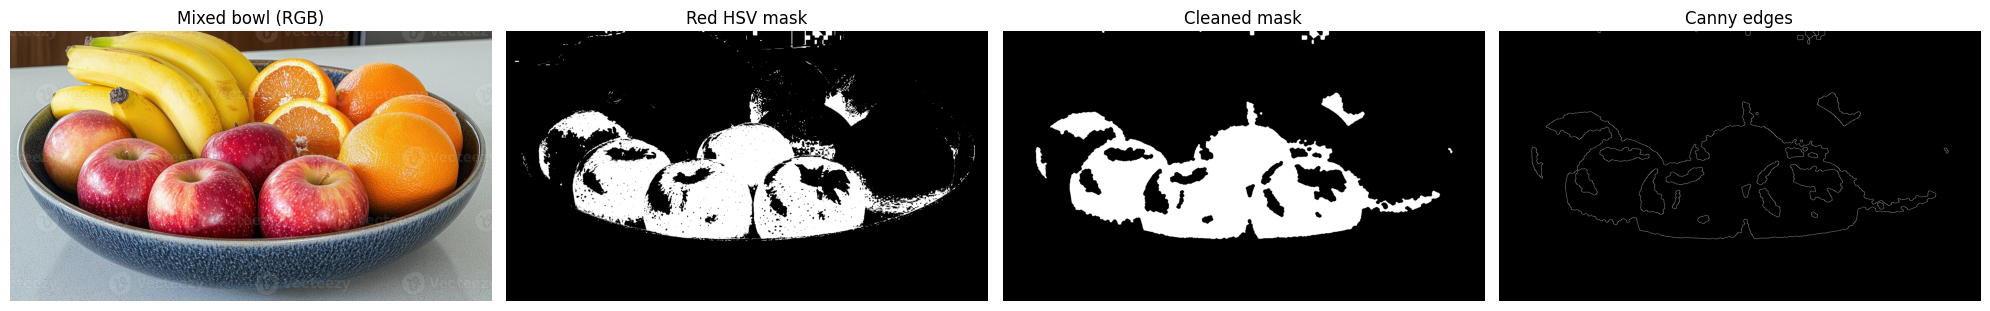

In [90]:
show_many(
    [rgb, raw_mask, clean_mask, edges],
    ["Mixed bowl (RGB)", "Red HSV mask", "Cleaned mask", "Canny edges"],
    cmap="gray",
)


In [91]:
contours, _ = cv.findContours(clean_mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
result = rgb.copy()
min_area = 8_000
apple_contours = [contour for contour in contours if cv.contourArea(contour) >= min_area]
for contour in apple_contours:
    x, y, width, height = cv.boundingRect(contour)
    cv.rectangle(result, (x, y), (x + width, y + height), (0, 255, 0), 3)
print(f"Red-apple regions localized: {len(apple_contours)}")


Red-apple regions localized: 1


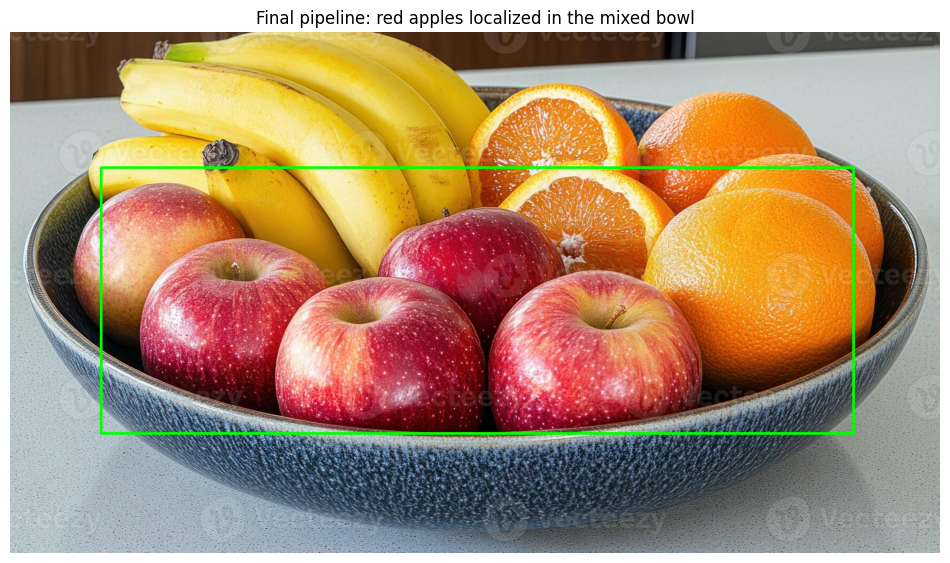

In [92]:
plt.figure(figsize=(12, 7))
plt.imshow(result)
plt.title("Final pipeline: red apples localized in the mixed bowl")
plt.axis("off")
plt.show()


In [93]:
def safe_imwrite(filename, image):
    """Write an RGB or grayscale image after validating the OpenCV input."""
    output_image = np.clip(image, 0, 255).astype(np.uint8)
    if output_image.ndim == 3:
        output_image = cv.cvtColor(output_image, cv.COLOR_RGB2BGR)
    if not cv.imwrite(filename, output_image):
        raise OSError(f"Could not save {filename}")
    print(f"Saved: {filename}")


In [94]:
safe_imwrite("final_pipeline_result.jpg", result)


Saved: final_pipeline_result.jpg


# Final Report

## Pipeline Summary

The completed workflow combines HSV segmentation, morphological cleanup, Canny boundaries, contour filtering, bounding boxes, and safe output writing. In the final example, two red hue intervals isolate apple pixels in the mixed bowl, then opening and closing improve the mask before localisation.

The method is suitable for controlled scenes, but fixed thresholds should be retuned for different lighting, cameras, or fruit colours. The Hough count is generated programmatically so it remains traceable whenever its parameters are changed.


# Conclusion

This assignment applied core OpenCV methods for colour analysis, contrast enhancement, denoising, manual Sobel filtering, binary morphology, Canny edges, Harris corners, Hough circles, and a full fruit-localisation workflow.

The experiments show that colour segmentation works best when it is followed by mask cleanup and shape analysis. HSV provides a practical starting point for controlled fruit images, while morphology improves the quality of the regions passed to later detection stages.
